# 03 SK-like detector
Toy expected event spectrum.

In [1]:
from pathlib import Path
import os, sys
PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "outputs" / "mplconfig"))
(PROJECT / "outputs").mkdir(exist_ok=True)
(PROJECT / "outputs" / "mplconfig").mkdir(exist_ok=True)
sys.path.insert(0, str(PROJECT / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solar_neutrino.spectra import load_b8_spectrum, normalize_spectrum, interpolate_spectrum
from solar_neutrino.oscillations import OscillationParameters, compute_survival_probability_grid
from solar_neutrino.cross_sections import nu_e_elastic_toy
from solar_neutrino.detector import efficiency, resolution_sigma, expected_events

## Inputs

In [2]:
E, shape = load_b8_spectrum(PROJECT / "data" / "b8_spectrum.csv")
shape = normalize_spectrum(E, shape); interp = interpolate_spectrum(E, shape)
E_bins = np.linspace(3.0, 15.0, 13); E_centers = 0.5 * (E_bins[:-1] + E_bins[1:])
flux_centers = interp(E_centers); pee_centers = compute_survival_probability_grid(E_centers, OscillationParameters())

## Detector response

In [3]:
xs = nu_e_elastic_toy(E_centers); eff = efficiency(E_centers); sigma_E = resolution_sigma(E_centers)
pd.DataFrame({"E_MeV": E_centers, "efficiency": eff, "resolution_sigma_MeV": sigma_E}).head()

,E_MeV,efficiency,resolution_sigma_MeV
0,3.5,0.075858,0.280624
1,4.5,0.500000,0.318198
2,5.5,0.924142,0.351781
3,6.5,0.993307,0.382426
4,7.5,0.999447,0.410792


## Expected event spectrum

In [4]:
exposure = 2200.0
expected = expected_events(E_bins, flux_centers, pee_centers, xs * eff, exposure=exposure)
summary = pd.DataFrame({"E_low_MeV": E_bins[:-1], "E_high_MeV": E_bins[1:], "E_center_MeV": E_centers, "expected": expected})
summary.to_csv(PROJECT / "outputs" / "expected_spectrum.csv", index=False)
summary

,E_low_MeV,E_high_MeV,E_center_MeV,expected
0,3.0,4.0,3.5,13.906251
1,4.0,5.0,4.5,152.841687
2,5.0,6.0,5.5,404.488109
3,6.0,7.0,6.5,560.640804
4,7.0,8.0,7.5,669.933823
5,8.0,9.0,8.5,740.141623
6,9.0,10.0,9.5,761.162886
7,10.0,11.0,10.5,725.002963
8,11.0,12.0,11.5,630.387875
9,12.0,13.0,12.5,485.377885


## Plot and threshold variation

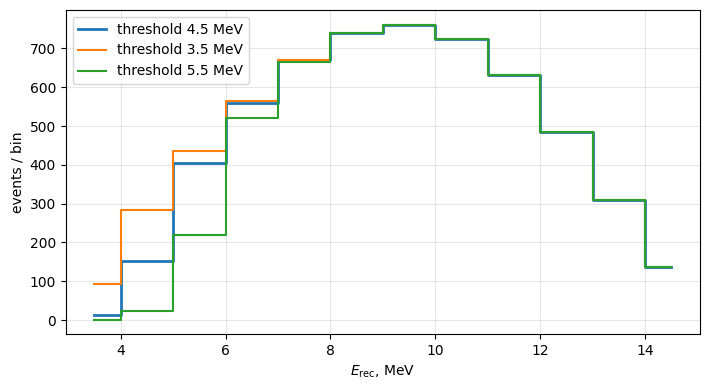

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.step(E_centers, expected, where="mid", lw=2, label="threshold 4.5 MeV")
for threshold in [3.5, 5.5]:
    expected_t = expected_events(E_bins, flux_centers, pee_centers, xs * efficiency(E_centers, threshold=threshold), exposure=exposure)
    ax.step(E_centers, expected_t, where="mid", label=f"threshold {threshold} MeV")
ax.set_xlabel(r"$E_{\rm rec}$, MeV"); ax.set_ylabel("events / bin"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(PROJECT / "outputs" / "threshold_variation.png", dpi=160); plt.show()